# <span style="color: red; font-weight:bold"> Causal. Ecommerce User Behavior - Project
### <span style="color: brown; font-weight:bold"> E-Commerce Synthetic Behavior Data Set; Factors-Tire Classification; LiNGAM; PC Algorithm.
### <span style="color: brown; font-weight:bold"> DoWhy DAG, ATE-Estimation and Refutation Test.

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# LinGAM
from causallearn.search.FCMBased.lingam import DirectLiNGAM
from causallearn.utils.PCUtils.BackgroundKnowledge import BackgroundKnowledge
from causallearn.graph.GraphNode import GraphNode

# PC algorithm
from causallearn.search.ConstraintBased.PC import pc
from causallearn.utils.cit import fisherz

# Draw DAG
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# DoWhy
import dowhy
from dowhy import CausalModel

from networkx.drawing.nx_pydot import read_dot
import re

import pydot

import warnings 
warnings.filterwarnings('ignore', category=FutureWarning) 
warnings.filterwarnings('ignore', category=RuntimeWarning) 


### Column Descriptors

`user_id`: Unique identifier for each user

`age`: Age of the user (years)

`gender`: Gender of the user (Male/Female)

`device_type`: Device used to access the platform (Mobile/Desktop/Tablet)

`time_on_site`: Total time spent on the website (minutes)

`pages_viewed`: Number of pages viewed during the session

`previous_purchases`: Total number of past purchases made by the user

`cart_items`: Number of items added to the cart

`discount_seen`: Whether the user was shown a discount (0 = No, 1 = Yes)

`ad_clicked`: Whether the user clicked on an advertisement (0 = No, 1 = Yes)

`returning_user`: Whether the user is a returning customer (0 = No, 1 = Yes)

`avg_session_time`: Average time spent per session (minutes)

`bounce_rate`: Percentage of sessions where the user left immediately (0–100)

`purchase`: Target variable indicating whether the user made a purchase (0 = No, 1 = Yes)


## T1 — Exogenous user attributes :
    randint(18, 60) — typical adult online shopper age range. Nothing clever, just realistic bounds.
    binomial(1, 0.5) for gender — 50/50 split, no reason to skew it.
    binomial(1, 0.35) for returning user — industry benchmark is roughly 25-40% of ecommerce traffic is returning visitors. 0.35 sits in the middle of that range.
    poisson(3) for previous purchases — Poisson is the natural distribution for count data (number of events). Mean=3 means the average user has bought 3 times before. .clip(0, 14) just caps unrealistic outliers. You could use mean=5 for a loyalty-heavy site, mean=1 for a new site.

### T2 — Session behaviour
    5 — baseline session time in minutes. Industry average for ecommerce is 3-8 minutes. 5 is a reasonable middle.
    0.3 * previous_purchases — a user with 10 past purchases adds 3 minutes vs a new user. Small but meaningful effect. This number is a judgment call — you're saying loyalty adds about 30 seconds per prior purchase.
    2.0 * returning_user — returning users spend 2 extra minutes on average. Plausible — they know where to look, they browse more intentionally.
    normal(0, 3) — random noise with std=3 minutes. This means ±3 min of unexplained variation, which is realistic.
    .clip(0.5, 45) — no session under 30 seconds (bounce), no session over 45 min (unrealistic).
    The rule for T2: baseline + small coefficients for each T1 cause + noise. The coefficients should be small enough that T1 explains maybe 20-40% of the variance — the rest is noise. If T1 explains 90% of T2 variance, your data is unrealistically deterministic.

### T3 — Interventions
    Simple — just realistic industry rates. Ecommerce discount exposure rates vary from 20-60%. Ad click-through rates on site are typically 15-30%. These are the only two numbers you need to justify, and both have published industry benchmarks.

We could make discount_seen depend on returning_user if you want a `confounder`:
```python
# Returning users more likely to get targeted discounts
discount_prob = 0.30 + 0.20 * returning_user   # 30% new, 50% returning
discount_seen = np.random.binomial(1, discount_prob, n)
```
    That one change creates a real backdoor path returning_user → discount_seen → purchase
    and tests whether your DoWhy pipeline correctly identifies and adjusts for it.

### T4 — The target (the most important part)
    For ecommerce a simple mental model works:
    Strong drivers    (0.3 - 0.5):  discount_seen, cart_items count
    Medium drivers    (0.1 - 0.2):  ad_clicked, returning_user
    Weak drivers      (0.02-0.08):  session time, pages viewed
    Negative drivers  (-0.01-0.03): bounce_rate (higher bounce = less likely)

## <span style="color: blue; font-weight:bold">Step 1. Synthetic Data Set Creation

In [62]:
np.random.seed(42)
# Number of observations
n = 8000

# T1 — exogenous user attributes
age                = np.random.randint(18, 60, n)
gender             = np.random.binomial(1, 0.5, n)
device_type        = np.random.choice([1, 2, 3], n)
returning_user     = np.random.binomial(1, 0.35, n)  # 35% returning
previous_purchases = np.random.poisson(3, n).clip(0, 14)

# T2 — session behaviour (causally influenced by T1)
avg_session_time = (
    8 + 0.3 * previous_purchases
    + 2 * returning_user
    + np.random.normal(0, 3, n)
).clip(0.5, 45)

# -----------------------
pages_viewed = (
    7 + 0.2 * previous_purchases
    + device_type
    + 0.8 * returning_user
    + np.random.normal(0, 1.5, n)
).clip(1, 17).round() 

time_on_site = (
    5 + 0.3 * previous_purchases
    + 0.7 * returning_user
    + 0.5 * pages_viewed
    + np.random.normal(0, 3, n)
).clip(0.5, 30)

# -----------------------

cart_items = (
    0.5 * previous_purchases
    + 0.1 * avg_session_time
    + np.random.normal(0, 1.5, n)
).clip(0, 9).round()

bounce_rate = (
    80 - 1.5 * avg_session_time
    - 3 * returning_user
    + np.random.normal(0, 10, n)
).clip(0, 100)

# T3 — interventions
discount_seen = np.random.binomial(1, 0.4, n)  # shown to 40%
ad_clicked    = np.random.binomial(1, 0.25, n)

# T4 — target with realistic ~8% base conversion rate
log_odds = (
    - 2.5                          # base rate; target => 8% 
    # -3.5  -> gives ~1.6%  (too low)
    # -3.0  -> gives ~5%    (low-end realistic)
    # -2.5  -> gives ~8%    (good ecommerce baseline)
    # -1.5  -> gives ~18%   (high-conversion site)
    + 0.08 * cart_items           # strong driver
    + 0.05 * previous_purchases   # loyalty signal
    - 0.02 * bounce_rate          # engagement signal
    + 0.03 * avg_session_time
    + 0.40 * discount_seen        # treatment effect
    + 0.15 * ad_clicked
    + 0.02 * pages_viewed       #  add small direct effect
    + 0.01 * time_on_site       #  add small direct effect
    + np.random.normal(0, 0.3, n)
)
purchase_prob = 1 / (1 + np.exp(-log_odds))
purchase      = np.random.binomial(1, purchase_prob, n)

In [63]:
print(f"Purchase rate: {purchase.mean():.1%}")
print(f"Purchase counts: {pd.Series(purchase).value_counts()}")

Purchase rate: 8.0%
Purchase counts: 0    7361
1     639
Name: count, dtype: int64


In [64]:
# Build the dataframe
df_synthetic = pd.DataFrame({
    'age':                age,
    'gender':             gender,
    'device_type':        device_type,
    'returning_user':     returning_user,
    'previous_purchases': previous_purchases,
    'time_on_site':       time_on_site,
    'pages_viewed':       pages_viewed,
    'avg_session_time':   avg_session_time,
    'cart_items':         cart_items,
    'bounce_rate':        bounce_rate,
    'discount_seen':      discount_seen,
    'ad_clicked':         ad_clicked,
    'purchase':           purchase
})

print("=== Number's  Effects ===\n")

# 1. Discount effect — purchase rate with vs without discount
rate_discount_1 = df_synthetic[df_synthetic['discount_seen']==1]['purchase'].mean()
rate_discount_0 = df_synthetic[df_synthetic['discount_seen']==0]['purchase'].mean()
print(f"Purchase rate WITH discount:     {rate_discount_1:.1%}")
print(f"Purchase rate WITHOUT discount:  {rate_discount_0:.1%}")
print(f"Raw lift:                        {rate_discount_1 - rate_discount_0:.1%}")
print(f"Expected (approx):               3-5%\n")  # from logistic math

# 2. Cart items effect
print(f"Avg cart_items | purchase=1:     {df_synthetic[df_synthetic['purchase']==1]['cart_items'].mean():.2f}")
print(f"Avg cart_items | purchase=0:     {df_synthetic[df_synthetic['purchase']==0]['cart_items'].mean():.2f}\n")

# 3. Bounce rate effect (should be negative)
print(f"Avg bounce_rate | purchase=1:    {df_synthetic[df_synthetic['purchase']==1]['bounce_rate'].mean():.1f}")
print(f"Avg bounce_rate | purchase=0:    {df_synthetic[df_synthetic['purchase']==0]['bounce_rate'].mean():.1f}\n")

# 4. Returning user effect
rate_returning_1 = df_synthetic[df_synthetic['returning_user']==1]['purchase'].mean()
rate_returning_0 = df_synthetic[df_synthetic['returning_user']==0]['purchase'].mean()
print(f"Purchase rate returning users:   {rate_returning_1:.1%}")
print(f"Purchase rate new users:         {rate_returning_0:.1%}\n")

# 5. Class balance
print(f"=== Class Balance ===")
print(df_synthetic['purchase'].value_counts())
print(f"Positive rate: {df_synthetic['purchase'].mean():.1%}")

=== Number's  Effects ===

Purchase rate WITH discount:     9.8%
Purchase rate WITHOUT discount:  6.8%
Raw lift:                        3.0%
Expected (approx):               3-5%

Avg cart_items | purchase=1:     2.86
Avg cart_items | purchase=0:     2.48

Avg bounce_rate | purchase=1:    61.1
Avg bounce_rate | purchase=0:    64.7

Purchase rate returning users:   8.9%
Purchase rate new users:         7.5%

=== Class Balance ===
purchase
0    7361
1     639
Name: count, dtype: int64
Positive rate: 8.0%


In [8]:
df_synthetic.describe()

,age,gender,device_type,returning_user,previous_purchases,time_on_site,pages_viewed,avg_session_time,cart_items,bounce_rate,discount_seen,ad_clicked,purchase
count,8000.000000,8000.000000,8000.00000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,38.598500,0.490125,2.00175,0.356375,2.991625,11.140357,9.872625,9.622312,2.511375,64.434955,0.403625,0.235500,0.079875
std,12.027744,0.499934,0.81675,0.478958,1.719571,3.208313,1.823819,3.221048,1.694028,11.596634,0.490655,0.424337,0.271117
min,18.000000,0.000000,1.00000,0.000000,0.000000,0.500000,3.000000,0.500000,0.000000,14.358621,0.000000,0.000000,0.000000
25%,28.000000,0.000000,1.00000,0.000000,2.000000,8.975360,9.000000,7.418305,1.000000,56.536378,0.000000,0.000000,0.000000
50%,39.000000,0.000000,2.00000,0.000000,3.000000,11.153219,10.000000,9.600529,2.000000,64.532596,0.000000,0.000000,0.000000
75%,49.000000,1.000000,3.00000,1.000000,4.000000,13.323162,11.000000,11.823061,4.000000,72.062163,1.000000,0.000000,0.000000
max,59.000000,1.000000,3.00000,1.000000,13.000000,23.448628,16.000000,20.816931,9.000000,100.000000,1.000000,1.000000,1.000000


In [52]:
print("=== Feature correlations ===")
cols = ['pages_viewed', 'time_on_site', 'avg_session_time']
print(df_synthetic[cols].corr().round(3))
print(f"\nPages viewed range:  {pages_viewed.min():.0f} - {pages_viewed.max():.0f}")
print(f"Time on site range:  {time_on_site.min():.1f} - {time_on_site.max():.1f}")
print(f"Avg session range:   {avg_session_time.min():.1f} - {avg_session_time.max():.1f}")

=== New set feature correlations ===
                  pages_viewed  time_on_site  avg_session_time
pages_viewed             1.000         0.331             0.110
time_on_site             0.331         1.000             0.082
avg_session_time         0.110         0.082             1.000

Pages viewed range:  3 - 16
Time on site range:  0.5 - 23.4
Avg session range:   0.5 - 20.8


## <span style="color: blue; font-weight:bold">Step 2 - Tier Assignment

In [9]:
# Copy synthetic data set
factors_set_df = df_synthetic.copy(deep=True)

In [10]:
# Tier 1 — Exogenous (upstream, not caused by the system)
'''
Slow-moving user attributes — low causal uncertainty
'''
list_tier_1 = ['age', 'gender', 'device_type', 'returning_user', 'previous_purchases']

# Tier 2 — Endogenous (caused by AND causes target)
'''
Session-level behaviour — bidirectional causal risk
'''
list_tier_2 = ['time_on_site', 'pages_viewed', 'cart_items', 'avg_session_time', 'bounce_rate']

# Tier 3 — Intervention signals (treatment variables)
'''
Key causal levers — high uncertainty, possible confounding
'''
list_tier_3 = ['discount_seen', 'ad_clicked']

# Tier 4 — Target variable
list_tier_4 = ['purchase'] # (binary 0/1)

In [11]:
# Wiyhin Tire data sets
factors_tier1_df = factors_set_df[list_tier_1]
factors_tier2_df = factors_set_df[list_tier_2]
factors_tier3_df = factors_set_df[list_tier_3]

In [12]:
# Lists of factors and target
factors = [
    'age', 'gender', 'device_type', 'returning_user', 'previous_purchases',
    'time_on_site', 'pages_viewed', 'cart_items', 'avg_session_time', 'bounce_rate',
    'discount_seen', 'ad_clicked'
          ]
target = 'purchase'

## <span style="color: blue; font-weight:bold">Step 3 LiNGAM Causal Discovery

In [13]:
def run_lingam_optim(df, factors, target):

    """
    LiNGAM finds full causal ordering using non-Gaussianity.  
    Parameters:
        df:                 full DataFrame
        factors:            list of factor names (plain list)
        target:             target column name string        
    Returns:
        named_order: factors sorted from most upstream to most downstream
        B          : adjacency matrix
    """
    
    data = df.copy()
    
    all_vars = factors + [target]
    X = data[all_vars].dropna().values
    X = (X - X.mean(axis=0)) / X.std(axis=0)
    
    n_vars = len(all_vars)
    target_idx = all_vars.index(target)
    
    # --- Prior knowledge matrix --------------------------------
    # LiNGAM prior_knowledge conventions:
    #   -1 = no constraint
    #    0 = i does NOT cause j  (forbidden edge i-->j)
    #    1 = i DOES cause j      (required edge)
    #
    # We build an (n x n) matrix where entry [i, j] concerns i-->j
    # Rule: target cannot cause any factor
    #       i.e. row target_idx must be all zeros (target→anything forbidden)
    
    prior = np.full((n_vars, n_vars), -1)  # start: all unconstrained
    
    # Forbid target → any factor (target row = 0)
    prior[target_idx, :] = 0
    
    # Also forbid anything → target EXCEPT we leave those unconstrained
    # (we WANT factors → target to be discovered freely)
    
    # Diagonal must be 0 (no self-causation)
    np.fill_diagonal(prior, 0)
    # -------------------------------------------------------------
    
    model = DirectLiNGAM(prior_knowledge=prior)  
    model.fit(X)
 
    order = model.causal_order_
    named_order = [all_vars[i] for i in order]
    
    B = pd.DataFrame(
        model.adjacency_matrix_,
        index=all_vars,
        columns=all_vars
    )
            
    order_rank = {var: rank for rank, var in enumerate(named_order)}
    B['causal_order_rank'] = [order_rank[var] for var in B.index]
    B['direct_effect_on_target'] = B[target].abs()
    
    return named_order, B

In [14]:
# Use
order, B = run_lingam_optim(
    factors_set_df,
    factors=factors,        # plain list
    target=target
)
# B[i,j] ≠ 0 means j has direct causal effect on i
order

['purchase',
 'ad_clicked',
 'returning_user',
 'discount_seen',
 'gender',
 'device_type',
 'age',
 'previous_purchases',
 'cart_items',
 'avg_session_time',
 'bounce_rate',
 'pages_viewed',
 'time_on_site']

In [15]:
lingam_summary = B[[
    'causal_order_rank', 
    'direct_effect_on_target']].sort_values('causal_order_rank')
lingam_summary

,causal_order_rank,direct_effect_on_target
purchase,0,0.000000
ad_clicked,1,0.000000
returning_user,2,0.000000
discount_seen,3,0.047154
gender,4,0.000000
device_type,5,0.000000
age,6,0.000000
previous_purchases,7,0.035478
cart_items,8,0.033596
avg_session_time,9,0.045800


In [16]:
# Sort by 'direct_effect_on_target'
print("\n=== Direct effects on target ===")
print(B[['causal_order_rank', 'direct_effect_on_target']]
      .sort_values('direct_effect_on_target', ascending=False)
      .to_string())


=== Direct effects on target ===
                    causal_order_rank  direct_effect_on_target
bounce_rate                        10                 0.049854
discount_seen                       3                 0.047154
avg_session_time                    9                 0.045800
previous_purchases                  7                 0.035478
cart_items                          8                 0.033596
returning_user                      2                 0.000000
device_type                         5                 0.000000
gender                              4                 0.000000
age                                 6                 0.000000
time_on_site                       12                 0.000000
pages_viewed                       11                 0.000000
ad_clicked                          1                 0.000000
purchase                            0                 0.000000


In [17]:
# Create a background knowledge from the LiNGRAM to PC Alhorithm
def lingam_order_to_pc_background(named_order, target, all_vars):
    """
    Convert LiNGAM causal order into PC background knowledge

    If variable A is ranked before B in LiNGAM order,
    forbid edge B -> A in PC.
    This dramatically reduces PC's search space and
    improves reliability.
    """
    
    # --- Verification --------------------------------------------
    if target not in named_order:
        raise ValueError(
            f"'{target}' not found in named_order. "
            f"append '{target}' at the end."
        )
    if named_order[-1] != target:
        raise ValueError(
            f"'{target}' must be last in named_order. "
            f"Currently at rank {named_order.index(target)}. "
            f"Append it at the end."
        )
    # -------------------------------------------------------------
    
    bk = BackgroundKnowledge()
    skipped = set()
    n = len(named_order)
    
    for i in range(n):
        for j in range(i+1, n):
            earlier_var = named_order[i]
            later_var   = named_order[j]
            
            if earlier_var not in all_vars:
                skipped.add(earlier_var)
                continue
            if later_var not in all_vars:
                skipped.add(later_var)
                continue
            
            # Create GraphNode objects by name.
            earlier_node = GraphNode(earlier_var)
            later_node   = GraphNode(later_var)
            
            # Forbid: later_var → earlier_var
            bk.add_forbidden_by_node(later_node, earlier_node)
    
    if skipped:
        print(f"  Skipped (not in Stage 2): {sorted(skipped)}")
    
    return bk

In [65]:
# Filter survived factors
stage2_factors = B.query('direct_effect_on_target > 0').index.to_list()
stage2_factors

['previous_purchases',
 'cart_items',
 'avg_session_time',
 'bounce_rate',
 'discount_seen']

In [19]:
lingam_target = 'purchase'
# Create order_lingam list with no 'target'
order_lingam = [v for v in order if v != lingam_target]

In [20]:
order_lingam

['ad_clicked',
 'returning_user',
 'discount_seen',
 'gender',
 'device_type',
 'age',
 'previous_purchases',
 'cart_items',
 'avg_session_time',
 'bounce_rate',
 'pages_viewed',
 'time_on_site']

## <span style="color: blue; font-weight:bold">Step 4 PC Alhorithm Causal Discovery

In [21]:
# Add forced factors for PC input despite of the LiNGAM results
# as they are the treatment variables 
forced_factors = 'ad_clicked'

In [22]:
# PS Alhorithm with background LiNGAM knowledge
def run_pc_stage3(df, stage2_factors, target,
                  named_order_lingam, forced_factors,
                  tier1_factors, tier2_factors, tier3_factors,
                  alpha=0.05):
    """
    Stage 3 PC run using LiNGAM ordering as background knowledge.
    
    Parameters:
        stage2_factors:      list of factors surviving Stage 2
        named_order_lingam:  causal order from run_lingam_optim                             
        tier1/2/3_factors:   original tier lists — used to add
                             tier-level forbidden edges on top
                             of LiNGAM ordering
    """

    data = df.copy()

    all_vars    = stage2_factors + [forced_factors] + [target]
    data_matrix = data[all_vars].dropna().values
    data_matrix = (data_matrix - data_matrix.mean(axis=0)) / data_matrix.std(axis=0)

    # --- Remove near-duplicate columns ---------------------------------
    corr    = np.corrcoef(data_matrix.T)
    to_drop = set()
    for i in range(len(all_vars)):
        for j in range(i+1, len(all_vars)):
            if abs(corr[i, j]) > 0.95 and j not in to_drop:
                to_drop.add(j)
    
    # Capture names BEFORE reassigning all_vars
    dropped_names = [all_vars[i] for i in sorted(to_drop)]
    
    keep_idx    = [i for i in range(len(all_vars)) if i not in to_drop]
    data_matrix = data_matrix[:, keep_idx]
    all_vars    = [all_vars[i] for i in keep_idx]
    
    if dropped_names:
        print(f"  Dropped near-duplicates: {dropped_names}")
    # -------------------------------------------------------------------

    print(f"  PC input: {len(all_vars)} variables, "
          f"{data_matrix.shape[0]} observations")
    # -------------------------------------------------------------

    # ── Background knowledge: LiNGAM ordering --------------------
    bk = lingam_order_to_pc_background(
        named_order=named_order_lingam + [target],
        target      = target,
        all_vars    = all_vars
    )
    # -------------------------------------------------------------

    # ── Background knowledge: tier constraints -------------------
    t1_in_vars = [f for f in tier1_factors if f in all_vars]
    t2_in_vars = [f for f in tier2_factors if f in all_vars]
    t3_in_vars = [f for f in tier3_factors if f in all_vars]

    print(f"  T1 in PC: {t1_in_vars}")
    print(f"  T2 in PC: {t2_in_vars}")
    print(f"  T3 in PC: {t3_in_vars}")

    # Tier 3 cannot cause Tier 1 or Tier 2
    for t3_var in t3_in_vars:
        for upstream_var in t1_in_vars + t2_in_vars:
            bk.add_forbidden_by_node(
                GraphNode(t3_var),        # <- GraphNode by name
                GraphNode(upstream_var)
            )

    # Tier 2 cannot cause Tier 1
    for t2_var in t2_in_vars:
        for t1_var in t1_in_vars:
            bk.add_forbidden_by_node(
                GraphNode(t2_var),        # <- GraphNode by name
                GraphNode(t1_var)
            )

    # Target cannot cause anything
    for var in all_vars:
        if var != target:
            bk.add_forbidden_by_node(
                GraphNode(target),        # <- GraphNode by name
                GraphNode(var)
            )
    # -------------------------------------------------------------

    # --- Run PC ---------------------------------------------------
    cg = pc(data_matrix,
            alpha              = alpha,
            indep_test         = fisherz,
            stable             = True,
            background_knowledge = bk,
            node_names         = all_vars,   # <- pass names so output is readable
            show_progress      = True)
    # -------------------------------------------------------------

    return cg, all_vars

In [23]:
# Run Stage 3 PC Algorithm
cg_pc, vars_pc = run_pc_stage3(
    df                 = df_synthetic,
    stage2_factors     = stage2_factors,
    target             = 'purchase',
    named_order_lingam = order_lingam,
    forced_factors     = forced_factors,
    tier1_factors      = list_tier_1,
    tier2_factors      = list_tier_2,
    tier3_factors      = list_tier_3,
    alpha              = 0.05
)

  PC input: 7 variables, 8000 observations
  Skipped (not in Stage 2): ['age', 'device_type', 'gender', 'pages_viewed', 'returning_user', 'time_on_site']
  T1 in PC: ['previous_purchases']
  T2 in PC: ['cart_items', 'avg_session_time', 'bounce_rate']
  T3 in PC: ['discount_seen', 'ad_clicked']


  0%|          | 0/7 [00:00<?, ?it/s]

In [24]:
# Display the PC Alhorithm result
def display_pc_results(cg, all_vars):
    """
    Parse PC adjacency matrix into readable directed edges.
    
    causallearn adjacency matrix conventions:
        cg.G.graph[i, j] =  1 and cg.G.graph[j, i] = -1  -->  i --> j
        cg.G.graph[i, j] = -1 and cg.G.graph[j, i] =  1  -->  j --> i
        cg.G.graph[i, j] =  1 and cg.G.graph[j, i] =  1  -->  i --- j (undirected)
        cg.G.graph[i, j] =  0 and cg.G.graph[j, i] =  0  -->  no edge
    """
    print(f"\n{'='*60}")
    print(f"PC Result:")
    print(f"{'='*60}")
    
    g     = cg.G.graph
    n     = len(all_vars)
    
    directed   = []
    undirected = []
    
    for i in range(n):
        for j in range(i+1, n):
            if g[i, j] == 1 and g[j, i] == -1:
                directed.append((all_vars[i], all_vars[j], '-->'))
            elif g[i, j] == -1 and g[j, i] == 1:
                directed.append((all_vars[j], all_vars[i], '-->'))
            elif g[i, j] == 1 and g[j, i] == 1:
                undirected.append((all_vars[i], all_vars[j], '--'))
    
    print(f"\nDirected edges ({len(directed)}):")
    for cause, effect, arrow in sorted(directed, 
                                        key=lambda x: x[1]):
        print(f"  {cause:30s} {arrow}  {effect}")
    
    print(f"\nUndirected edges ({len(undirected)}):")
    for a, b, line in sorted(undirected):
        print(f"  {a:30s} {line}  {b}")
    
    # Specifically highlight edges pointing TO target
    print(f"\nDirect causes of {target}:")
    found = False
    for cause, effect, arrow in directed:
        if effect == target:
            print(f"  {cause:30s} -->  {target}")
            found = True
    if not found:
        print("  None found with directed edges")
    
    for a, b, _ in undirected:
        if target in (a, b):
            other = b if a == target else a
            print(f"  {other:30s} —  {target}  (undirected)")
    
    return directed, undirected

In [25]:
# Display PC Results 1
directed_edges, undirected_edges = display_pc_results(
    cg_pc, vars_pc
)


PC Result:

Directed edges (8):
  bounce_rate                    -->  avg_session_time
  purchase                       -->  avg_session_time
  purchase                       -->  bounce_rate
  avg_session_time               -->  cart_items
  purchase                       -->  cart_items
  purchase                       -->  discount_seen
  cart_items                     -->  previous_purchases
  avg_session_time               -->  previous_purchases

Undirected edges (0):

Direct causes of purchase:
  None found with directed edges


In [26]:
# Readable adjacency matrix
print("\nAdjacency matrix:")
pd.DataFrame(    cg_pc.G.graph,
    index=vars_pc,
    columns=vars_pc
)


Adjacency matrix:


,previous_purchases,cart_items,avg_session_time,bounce_rate,discount_seen,ad_clicked,purchase
previous_purchases,0,-1,-1,0,0,0,0
cart_items,1,0,-1,0,0,0,-1
avg_session_time,1,1,0,-1,0,0,-1
bounce_rate,0,0,1,0,0,0,-1
discount_seen,0,0,0,0,0,0,-1
ad_clicked,0,0,0,0,0,0,0
purchase,0,1,1,1,1,0,0


## <span style="color: blue; font-weight:bold">Step 5 Complete post-processing pipeline for PC output
    Correct edges that violate the constraint
    Remove any edge where a lower tier causes a higher tier.
    Remove nodes that have no directed path to the target.

In [27]:
# Correct edges that violate the constraint
def fix_forbidden_edges(cg, all_vars, target):
    """
    Post-process PC result to correct edges that violate
    the constraint: target cannot cause any factor.
    
    If target -> X was found, flip to X -> target
    or remove the edge if flipping creates a cycle.
    """
    import copy
    g = cg.G.graph.copy()
    target_idx = all_vars.index(target)
    n = len(all_vars)
    
    corrections = []
    
    for j in range(n):
        if j == target_idx:
            continue
        # Check if target → j (forbidden)
        if g[target_idx, j] == 1 and g[j, target_idx] == -1:
            corrections.append((target, all_vars[j], 'flip'))
            # Flip to j → target
            g[target_idx, j] = -1
            g[j, target_idx] =  1
    
    if corrections:
        print(f"  Corrected forbidden edges:")
        for src, dst, action in corrections:
            print(f"    {src} --> {dst}  FLIPPED TO  {dst} --> {src}")
    
    cg.G.graph = g
    return cg

In [28]:
def fix_tier_violations(directed_edges, tier1, tier2, tier3):
    """
    Remove any edge where a lower tier causes a higher tier.
    Tier 2 -> Tier 1 : impossible
    Tier 3 -> Tier 1 : impossible  
    Tier 3 -> Tier 2 : impossible
    """
    clean_edges = []
    removed = []
    
    for cause, effect, arrow in directed_edges:       
        violation = False
        # Tier 2 → Tier 1
        if cause in tier2 and effect in tier1:
            violation = True
        # Tier 3 → Tier 1
        if cause in tier3 and effect in tier1:
            violation = True
        # Tier 3 → Tier 2
        if cause in tier3 and effect in tier2:
            violation = True
            
        if violation:
            removed.append((cause, effect))
        else:
            clean_edges.append((cause, effect, arrow))
    
    if removed:
        print(f"Removed tier violations:")
        for c, e in removed:
            print(f"  {c} → {e}")
    
    return clean_edges


In [29]:
def remove_dead_end_nodes(directed_edges, target):
    """
    Remove nodes that have no directed path to the target.
    Iterates until no more dead-end nodes remain.
    
    A dead-end node is one with:
    - No outgoing edges pointing toward target (directly or indirectly)
    - i.e. it cannot reach target through any path
    """
    
    def get_reachable_from(edges, start_node):
        """Find all nodes reachable from start_node following edges."""
        reachable = set()
        frontier  = {start_node}
        edge_map  = {}
        for cause, effect, _ in edges:
            edge_map.setdefault(cause, set()).add(effect)
        
        while frontier:
            node = frontier.pop()
            for child in edge_map.get(node, set()):
                if child not in reachable:
                    reachable.add(child)
                    frontier.add(child)
        return reachable

    def can_reach_target(edges, target):
        """Return set of nodes that can reach the target."""
        # Reverse the graph
        reverse_map = {}
        for cause, effect, _ in edges:
            reverse_map.setdefault(effect, set()).add(cause)
        
        # BFS backwards from target
        can_reach  = {target}
        frontier   = {target}
        while frontier:
            node = frontier.pop()
            for parent in reverse_map.get(node, set()):
                if parent not in can_reach:
                    can_reach.add(parent)
                    frontier.add(parent)
        return can_reach

    current_edges = directed_edges.copy()
    
    while True:
        reachable_nodes = can_reach_target(current_edges, target)
        
        # Keep only edges where BOTH nodes can reach target
        # (or ARE the target)
        filtered = [
            (c, e, arrow) for c, e, arrow in current_edges
            if c in reachable_nodes and e in reachable_nodes
        ]
        
        removed_edges = [
            (c, e) for c, e, _ in current_edges
            if (c, e, '-->') not in [(x, y, a) for x, y, a in filtered]
        ]
        
        if len(filtered) == len(current_edges):
            break  # no more pruning needed
            
        if removed_edges:
            print(f"  Pruned dead-end edges: {removed_edges}")
        
        current_edges = filtered
    
    return current_edges

### <span style="color: brown"> Step 5.1. Fix forbidden target edges

In [30]:
# Apply corrections for the target direction
cg_pc_fixed = fix_forbidden_edges(cg_pc, vars_pc, target='purchase')

  Corrected forbidden edges:
    purchase --> cart_items  FLIPPED TO  cart_items --> purchase
    purchase --> avg_session_time  FLIPPED TO  avg_session_time --> purchase
    purchase --> bounce_rate  FLIPPED TO  bounce_rate --> purchase
    purchase --> discount_seen  FLIPPED TO  discount_seen --> purchase


In [31]:
# Re-display with corrected edges
directed_pc_fixed, undirected_pc_fixed = display_pc_results(
    cg_pc_fixed, vars_pc
)


PC Result:

Directed edges (8):
  bounce_rate                    -->  avg_session_time
  avg_session_time               -->  cart_items
  cart_items                     -->  previous_purchases
  avg_session_time               -->  previous_purchases
  cart_items                     -->  purchase
  avg_session_time               -->  purchase
  bounce_rate                    -->  purchase
  discount_seen                  -->  purchase

Undirected edges (0):

Direct causes of purchase:
  cart_items                     -->  purchase
  avg_session_time               -->  purchase
  bounce_rate                    -->  purchase
  discount_seen                  -->  purchase


### <span style="color: brown"> Step 5.2. Remove tier hierarchy violations

In [32]:
# Apply corrections for the tier constraints
directed_pc_clean = fix_tier_violations(
    directed_pc_fixed,
    tier1 = set(list_tier_1),
    tier2 = set(list_tier_2),
    tier3 = set(list_tier_3)
)

Removed tier violations:
  cart_items → previous_purchases
  avg_session_time → previous_purchases


### <span style="color: brown"> Step 5.3. Prune dead-end nodes

In [66]:
print("\n Dead End Nodes Removed") # No arrors to the 'target' dirrectly
directed_pc_edges_final = remove_dead_end_nodes(directed_pc_clean, target='purchase')

print("\nFinal Edges:")
for c, e, _ in directed_pc_edges_final:
    print(f"  {c:30s} -->  {e}")


 Dead End Nodes Removed

Final Edges:
  avg_session_time               -->  cart_items
  cart_items                     -->  purchase
  bounce_rate                    -->  avg_session_time
  avg_session_time               -->  purchase
  bounce_rate                    -->  purchase
  discount_seen                  -->  purchase


## <span style="color: blue; font-weight:bold"> Step 6. Create visual representations of causal relationships. Directed Acyclic Graphs (DAGs)

In [35]:
def draw_dag(directed_edges, 
             list_tier_1, list_tier_2, list_tier_3,
             title, figsize=(14, 8)):
    """
    Draw DAG from display_pc_results() directed edge list.
    directed_edges: list of (cause, effect, '→') tuples
    """
    G = nx.DiGraph()
    G.add_edges_from([(c, e) for c, e, _ in directed_edges])
    
    # Layout: topological sort gives natural top-to-bottom flow
    try:
        # Hierarchical layout using graphviz if available
        pos = nx.nx_agraph.graphviz_layout(G, prog='dot')
    except:
        # Fallback: spring layout
        pos = nx.spring_layout(G, seed=42, k=2)
    
    # Colour nodes by tier
    
    node_colors = []
    for node in G.nodes():
        if node in list_tier_1:
            node_colors.append('#AED6F1')   # light blue
        elif node in list_tier_2:
            node_colors.append('#A9DFBF')   # light green
        elif node in list_tier_3:
            node_colors.append('#F9E79F')   # light yellow
        elif node in target:
            node_colors.append('#F1948A')   # light red   — target
        else:
            node_colors.append('#D5D8DC')   # grey        — other
    
    fig, ax = plt.subplots(figsize=figsize)
    
    nx.draw_networkx(
        G, pos,
        ax           = ax,
        node_color   = node_colors,
        node_size    = 2000,
        font_size    = 12,
        font_weight  = 'bold',
        font_color   = 'blue',
        arrows       = True,
        arrowsize    = 20,
        edge_color   = '#2C3E50',
        width        = 1.5,
        connectionstyle = 'arc3,rad=0.1'
        #connectionstyle='arc3,rad=0'
    )
  
    # Legend
    legend_elements = [
        mpatches.Patch(color='#AED6F1', label='Tier 1'),
        mpatches.Patch(color='#A9DFBF', label='Tier 2'),
        mpatches.Patch(color='#F9E79F', label='Tier 3'),
        mpatches.Patch(color='#F1948A', label='Target'),
    ]
    ax.legend(handles=legend_elements, loc='best', fontsize=9)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=20)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

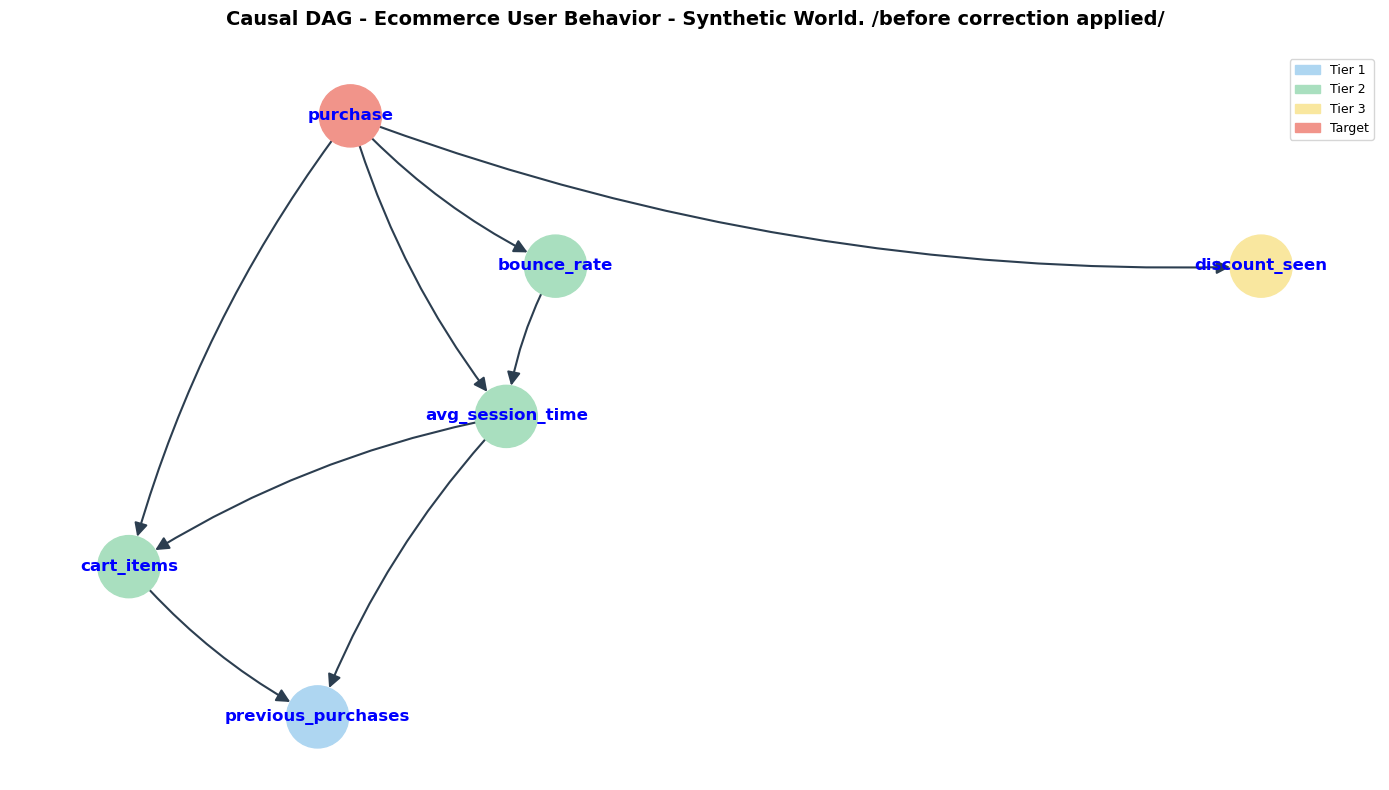

In [69]:
# Draw DAG with the directed_edges before correction applied
draw_dag(directed_edges, list_tier_1, list_tier_2, list_tier_3, "Causal DAG - Ecommerce User Behavior - Synthetic World. /before correction applied/")

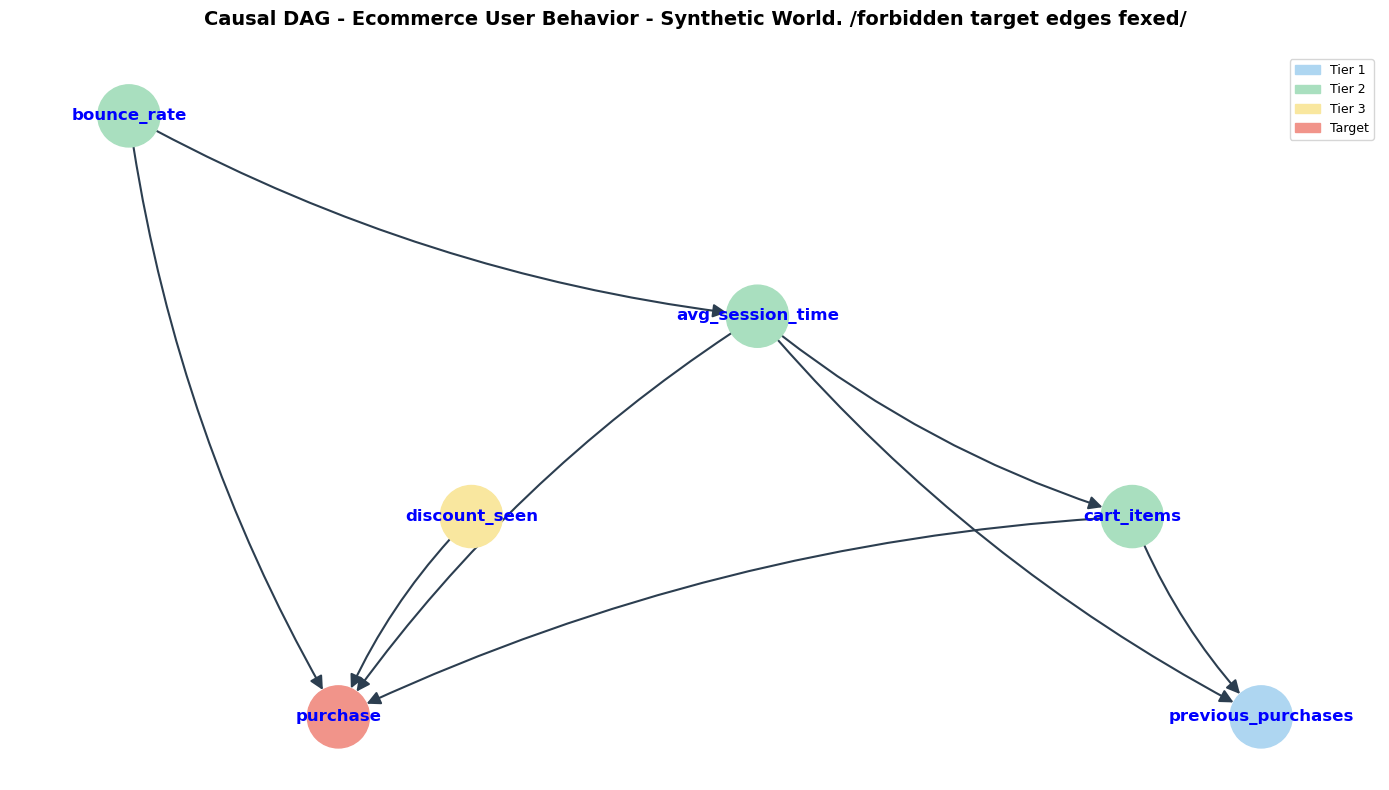

In [68]:
# Draw DAG after forbidden target edges fexed
draw_dag(directed_pc_fixed, list_tier_1, list_tier_2, list_tier_3, "Causal DAG - Ecommerce User Behavior - Synthetic World. /forbidden target edges fexed/")

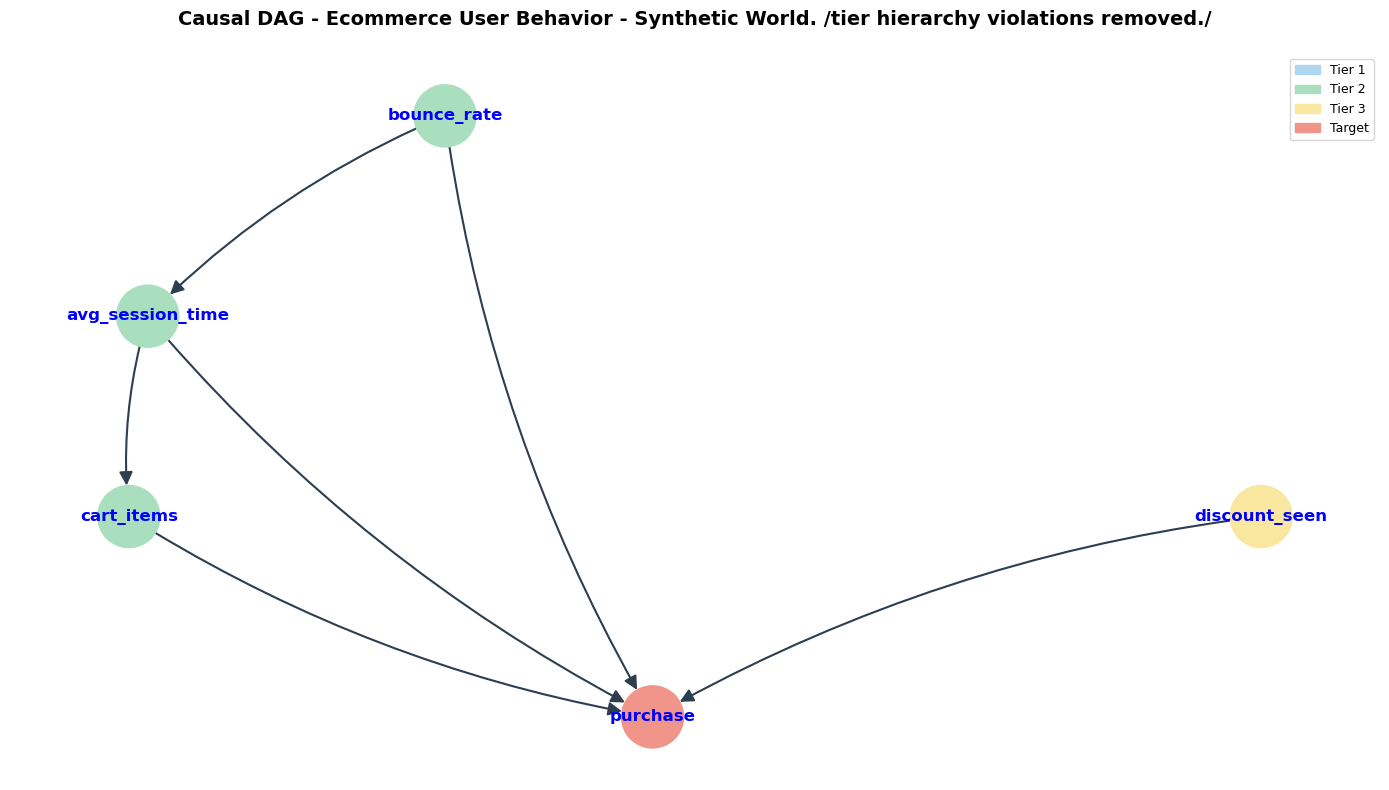

In [70]:
# Draw DAG after tier hierarchy violations removed.
draw_dag(directed_pc_clean, list_tier_1, list_tier_2, list_tier_3, "Causal DAG - Ecommerce User Behavior - Synthetic World. /tier hierarchy violations removed./")

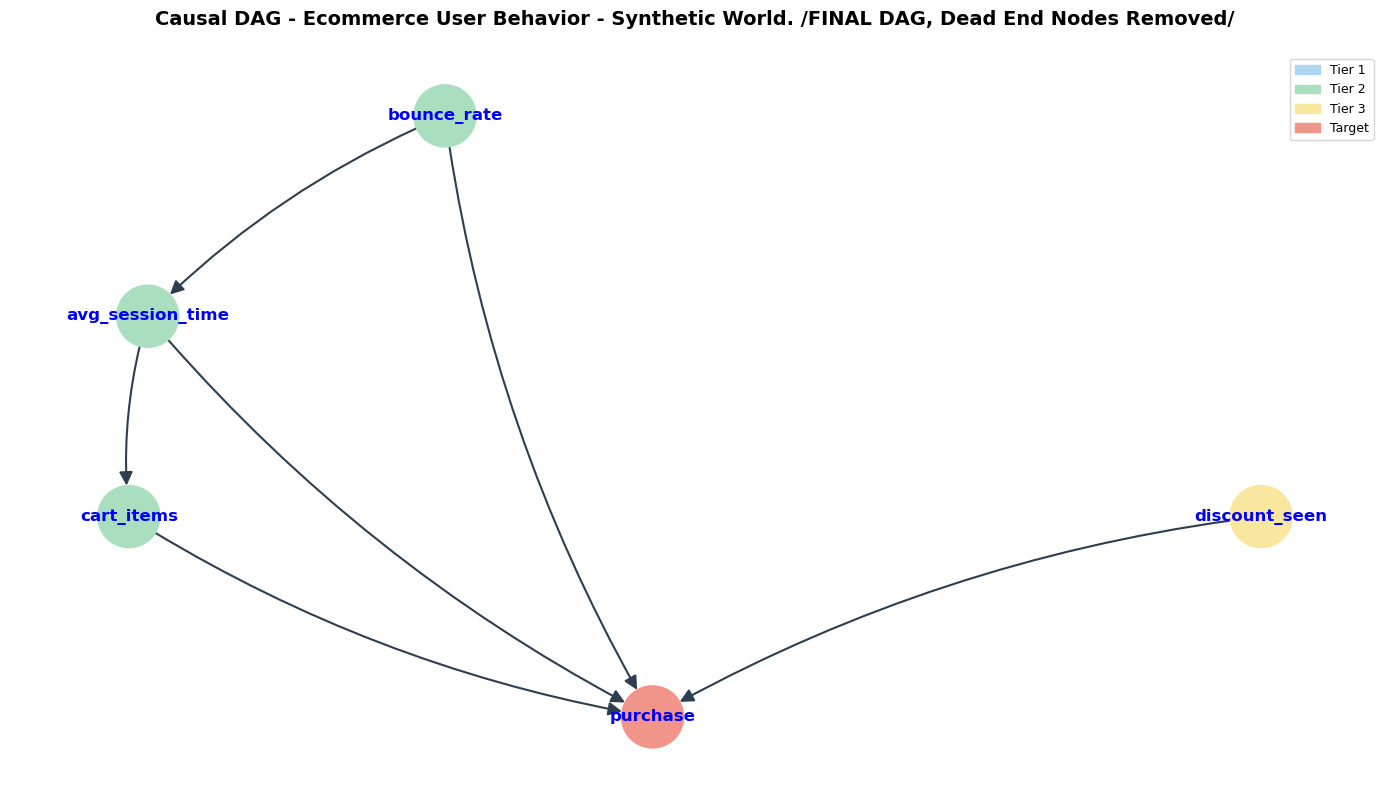

In [71]:
# Draw FINAL DAG, Dead End Nodes Removed
draw_dag(directed_pc_edges_final, list_tier_1, list_tier_2, list_tier_3, "Causal DAG - Ecommerce User Behavior - Synthetic World. /FINAL DAG, Dead End Nodes Removed/")

In [ ]:
# The DAG in DOT format - directly from PC output
causal_graph_dot = """
digraph {
    bounce_rate -> avg_session_time;
    avg_session_time -> cart_items;
    cart_items -> purchase;
    avg_session_time -> purchase;
    bounce_rate -> purchase;
    discount_seen -> purchase;
}
"""

## <span style="color: blue; font-weight:bold"> Step 7. ATE Estimation
`Meaningful Treatment Questions:`

    1. Does showing a discount cause purchase?
    2. Do more cart items cause purchase?
    3. Whether adding a domain-logically 'returning_user' changes the 'discount_seen' ATE?

In [75]:
# Primary: does showing a discount cause purchase?
model_discount = CausalModel(
    data       = factors_set_df,
    treatment  = 'discount_seen',
    outcome    = 'purchase',
    graph      = causal_graph_dot
)

# Secondary: do more cart items cause purchase?
model_cart   = CausalModel(
    data      = factors_set_df,
    treatment = 'cart_items',
    outcome   = 'purchase',
    graph     = causal_graph_dot
)

# bounce_rate
model_bounce   = CausalModel(
    data      = factors_set_df,
    treatment = 'bounce_rate',
    outcome   = 'purchase',
    graph     = causal_graph_dot
)

# avg_session_time
model_session_time   = CausalModel(
    data      = factors_set_df,
    treatment = 'avg_session_time',
    outcome   = 'purchase',
    graph     = causal_graph_dot
)

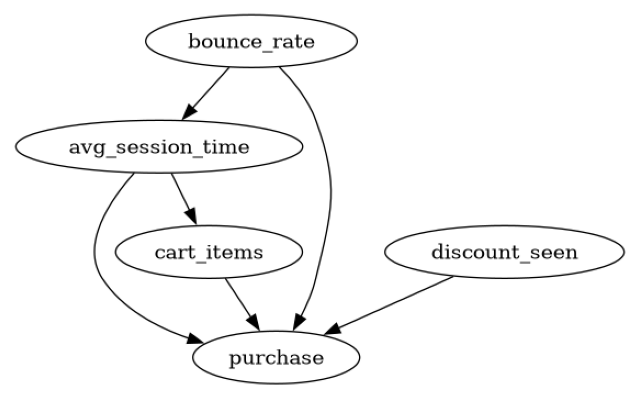

In [41]:
# Draw the causal graph directly from the DoWhy model
model_discount.view_model(size=(8, 6))

In [42]:
# Add counfounder
causal_graph_with_confounder = """
digraph {
    bounce_rate -> avg_session_time;
    avg_session_time -> cart_items;
    cart_items -> purchase;
    avg_session_time -> purchase;
    bounce_rate -> purchase;
    discount_seen -> purchase;
    returning_user -> discount_seen;
    returning_user -> purchase;
}
"""

In [43]:
# Check confounder =>  whether adding 'returning_user' as a confounder changes the discount_seen ATE?
model_with_confounder   = CausalModel(
    data      = factors_set_df,
    treatment = 'discount_seen',
    outcome   = 'purchase',
    graph     = causal_graph_with_confounder
)

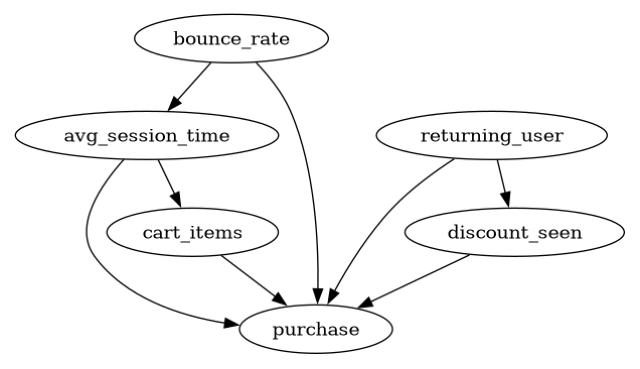

In [44]:
model_with_confounder.view_model(size=(8,6))

In [45]:
# ATE on target
'''
Tested on:
1. model_discount: "discount_seen"
2. model_cart "cart_items"
3. model_bounce: "bounce_rate"
4. model_session_time: "avg_session_time"
5. model_with_confounder: "returning_user"

'''
def ate_on_target(model):
    identified_beh   = model.identify_effect(proceed_when_unidentifiable=True)
    estimate_beh     = model.estimate_effect(
        identified_beh,
        method_name = "backdoor.linear_regression"   #  uses the backdoor criterion to select confounders, then runs linear regression
    )
    
    
    print(f"Causal effect -> target:")
    print(f"  ATE:   {estimate_beh.value:.6f}")

'''
The backdoor adjustment set DoWhy returns contains exactly the variables we need to control for
- typically confounders, never colliders or mediators (for total effect).
'''

'\nThe backdoor adjustment set DoWhy returns contains exactly the variables we need to control for\n- typically confounders, never colliders or mediators (for total effect).\n'

In [46]:
# discount_seen
ate_on_target(model_discount)

Causal effect -> target:
  ATE:   0.030812


In [47]:
# cart_items
ate_on_target(model_cart)

Causal effect -> target:
  ATE:   0.006990


In [73]:
# bounce_rate
ate_on_target(model_bounce)

Causal effect -> target:
  ATE:   -0.001993


In [76]:
# avg_session_time
ate_on_target(model_session_time)

Causal effect -> target:
  ATE:   0.004007


In [79]:
# Counfounder Test. returning_user
ate_on_target(model_with_confounder)

Causal effect -> target:
  ATE:   0.030909


## <span style="color: blue; font-weight:bold"> Step 8. Refutation Test

In [50]:
def run_refutations(model, identified, estimate, label):
    print(f"\n=== Refutations: {label} ===")
    
    # Test 1: Random common cause
    refute_random = model.refute_estimate(
        estimand    = identified,
        estimate    = estimate,
        method_name = "random_common_cause",
        random_seed = 42
    )
    print(f"Random common cause:\n{refute_random}")
    
    # Test 2: Placebo treatment
    refute_placebo = model.refute_estimate(
        estimand    = identified,
        estimate    = estimate,
        method_name = "placebo_treatment_refuter",
        random_seed = 42
    )
    print(f"Placebo treatment:\n{refute_placebo}")
    
    # Test 3: Data subset
    refute_subset = model.refute_estimate(
        estimand    = identified,
        estimate    = estimate,
        method_name = "data_subset_refuter",
        subset_fraction = 0.8,
        random_seed = 42
    )
    print(f"Data subset:\n{refute_subset}")

# Run :
def ate_full(model, label):
    identified = model.identify_effect(proceed_when_unidentifiable=True)
    estimate   = model.estimate_effect(
        identified,
        method_name = "backdoor.linear_regression"
    )
    print(f"\nATE [{label}]: {estimate.value:.6f}")
    run_refutations(model, identified, estimate, label)
    return identified, estimate

In [80]:
identified_discount, estimate_discount = ate_full(
    model_discount, "discount_seen -> purchase"
)


ATE [discount_seen -> purchase]: 0.030812

=== Refutations: discount_seen -> purchase ===
Random common cause:
Refute: Add a random common cause
Estimated effect:0.03081248212016159
New effect:0.030814195191482097
p value:1.0

Placebo treatment:
Refute: Use a Placebo Treatment
Estimated effect:0.03081248212016159
New effect:0.00015498148857759922
p value:1.0

Data subset:
Refute: Use a subset of data
Estimated effect:0.03081248212016159
New effect:0.030851841259227436
p value:0.94



In [81]:
# Run ate_full on cart_items — it has the strongest LiNGAM direct effect (0.053) and is the most interesting non-treatment variable. 
identified_discount_cart, estimate_discount_cart = ate_full(
    model_cart, "cart_items -> purchase"
)


ATE [cart_items -> purchase]: 0.006990

=== Refutations: cart_items -> purchase ===
Random common cause:
Refute: Add a random common cause
Estimated effect:0.006989760956129576
New effect:0.006989245210662219
p value:0.86

Placebo treatment:
Refute: Use a Placebo Treatment
Estimated effect:0.006989760956129576
New effect:0.0
p value:1.0

Data subset:
Refute: Use a subset of data
Estimated effect:0.006989760956129576
New effect:0.007054570800326692
p value:0.9199999999999999



In [78]:
# After DoWhy => New Synthetic ATE estimation

In [82]:
print("=== Ground Truth Recovery ===")
print(f"Planted lift :                0.032")
print(f"DoWhy ATE recovered:          {estimate_discount.value:.6f}")
print(f"Recovery error:               {abs(estimate_discount.value - 0.032)/0.032:.1%}")

=== Ground Truth Recovery ===
Planted lift :                0.032
DoWhy ATE recovered:          0.030812
Recovery error:               3.7%
